In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import ttest_rel
from sklearn.tree import DecisionTreeRegressor
from ngboost import NGBRegressor
from ngboost.distns import Normal
from matplotlib.patches import Patch

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset


SEED         = 42
N_EVAL_SEEDS = 50
np.random.seed(SEED); torch.manual_seed(SEED)

dtu_navy      = '#030F4F'
dtu_red       = '#990000'
dtu_grey      = '#DADADA'
dtu_grey_dark = '#636363'
phase2_red    = '#bc5959'
phase2_blue   = '#babecf'

textwidth_in = 6.38
fs           = 25

print(f'PyTorch {torch.__version__}  |  NGBoost  |  seed={SEED}  |  n_eval_seeds={N_EVAL_SEEDS}')

PyTorch 2.8.0+cpu  |  NGBoost  |  seed=42  |  n_eval_seeds=50


Stations: ['KPC_U' 'EGP' 'SCO_U' 'KAN_U' 'QAS_U' 'UPE_U']
KPC_U: Lat=79.91, Lon=-24.08
EGP: Lat=75.62, Lon=-35.97
KAN_U: Lat=67.0, Lon=-47.03
UPE_U: Lat=72.89, Lon=-54.3


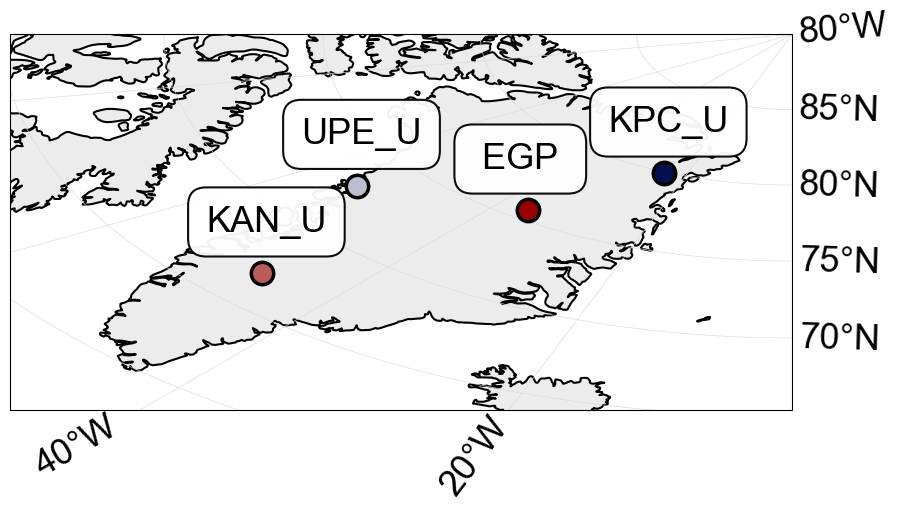

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap, Normalize, ListedColormap, BoundaryNorm
import matplotlib

matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 26  # Set default font size to 26

# DTU color scheme
dtu_navy = '#030F4F'
dtu_red = '#990000'
dtu_grey = '#DADADA'
white = '#ffffff'
black = '#000000'

# Color intermediates
phase2_red = '#bc5959'
phase2_blue = '#babecf'

# Custom colormaps
dtu_coolwarm_cmap = LinearSegmentedColormap.from_list("dtu_coolwarm", [dtu_navy, white, dtu_red])
dtu_blues_cmap = LinearSegmentedColormap.from_list("dtu_blues", ['#030f4f', white])
dtu_reds_cmap = LinearSegmentedColormap.from_list("dtu_reds", [white, dtu_red])

# Load the data
file_path = r"C:\Users\user\OneDrive\Desktop\DMI_project\Data\mashup_2025.csv"
df = pd.read_csv(file_path)

# Get unique stations
stations = df['station_id'].unique()
print("Stations:", stations)

# Define station coordinates (lat, lon)
station_coords = {
    'KPC_U': (79.91, -24.08),   # Kronprins Christian Land Upper
    'EGP': (75.62, -35.97),      # Egig Point (EastGRIP)
    'KAN_U': (67.00, -47.03),    # Kangerlussuaq Upper (S-10)
    'UPE_U': (72.89, -54.30)     # Upernavik Upper
}

# Station colors matching the histogram plot
colors = {
    "EGP": dtu_red,
    "KAN_U": phase2_red,
    "KPC_U": dtu_navy,
    "UPE_U": phase2_blue,
}

# Create the plot
fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9),
                       subplot_kw={'projection': ccrs.NorthPolarStereo()})
ax.set_extent([-82, -10, 65, 90], crs=ccrs.PlateCarree())  # zoom on Greenland

# Let the map fill the axes box instead of locking to data aspect
ax.set_aspect('auto')

# Add coastlines and features with DTU grey
ax.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor=black)
ax.add_feature(cfeature.LAND, facecolor=dtu_grey, alpha=0.5)

# Add gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, 
                  linewidth=0.5, color=dtu_grey, alpha=0.9, linestyle='-')
gl.left_labels = False   # remove latitude labels on the left y-axis
gl.xlabel_style = {'size': 26}
gl.ylabel_style = {'size': 26}

# Plot each station with annotations
for station_id, (lat, lon) in station_coords.items():
    if station_id in stations:  # Only plot stations that exist in your data
        
        # Plot dots - color matched to the histogram
        ax.scatter(lon, lat, s=260, color=colors[station_id], 
                   transform=ccrs.PlateCarree(), alpha=1, 
                   marker='o', edgecolors=black, linewidths=2.5, zorder=5)
        
        # Add spaces before and after EGP
        display_name = f' {station_id} ' if station_id == 'EGP' else station_id
        
        # Annotate each point
        ax.annotate(display_name, 
                    xy=(lon, lat), 
                    xytext=(-40, 30),  # offset in points
                    textcoords='offset points',
                    transform=ccrs.PlateCarree(),
                    fontsize=26,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor=white, 
                             edgecolor=black, alpha=0.95, linewidth=1.5),
                    zorder=6)
        
        print(f"{station_id}: Lat={lat}, Lon={lon}")

plt.tight_layout()
plt.show()

In [4]:
df_train = pd.read_csv('./filter_mu_atmo_surf_obs2345_promistK.csv')
df_test  = pd.read_csv('./mashup_2025.csv')
TARGET = 'promistK'

df_test_raw = df_test.copy()

def apply_filters(df):
    return df.loc[
        (df['lev1_sunzenith_angle'] >= 0)    & (df['lev1_sunzenith_angle'] < 180) &
        (df['lev1_satzenith_angle'] < 75)    &
        (df['satcenter_station_dist_km'] < 7) &
        (df['lev2_quality_level'] > 0)        &
        (df['lev2_surface_temperature'] > 200) & (df['lev2_surface_temperature'] < 270) &
        (df['CloudCover'] < 1.2)              &
        (df['nwp_t2m'] - df['nwp_d2m'] < 15) &
        (df['SurfaceTemperature(C)'] > 200 - 273.15) &
        (df['SurfaceTemperature(C)'] < 270 - 273.15)
    ].sort_values('lev1_obstime').reset_index(drop=True)

df_train = apply_filters(df_train)
df_test  = apply_filters(df_test)

for df in [df_train, df_test]:
    df['ch4_minus_skt'] = df['lev1_channel4'] - df['nwp_skt']

print(f'Train: {len(df_train):,}  Test: {len(df_test):,}')

Train: 3,430  Test: 284


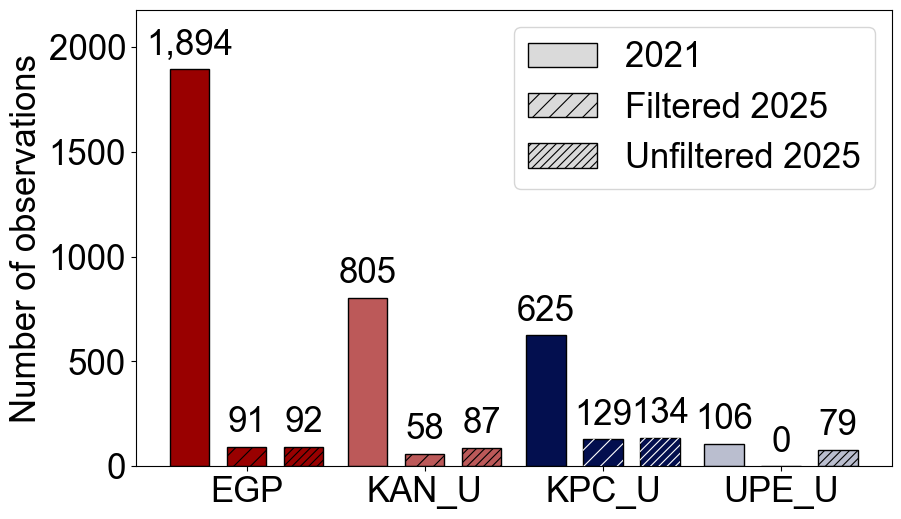

In [5]:
import matplotlib.dates as mdates

plt.rcParams.update({
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "legend.fontsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
})

# Histograms
stations = ["EGP", "KAN_U", "KPC_U", "UPE_U"]

train_counts    = df_train["station_id"].value_counts().reindex(stations, fill_value=0)
test_counts     = df_test["station_id"].value_counts().reindex(stations, fill_value=0)
test_raw_counts = df_test_raw["station_id"].value_counts().reindex(stations, fill_value=0)

colors = {
    "EGP": dtu_red,
    "KAN_U": phase2_red,
    "KPC_U": dtu_navy,
    "UPE_U": phase2_blue,
}

# Professional pattern scheme: solid / sparse diagonal / denser diagonal
hatch_2021    = None
hatch_2025    = '//'
hatch_2025raw = '////'

x = np.arange(len(stations))
width = 0.22
sep = 0.1
offset = width + sep

# Make hatch lines thinner and consistent for a cleaner look
plt.rcParams['hatch.linewidth'] = 0.8

fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))

# White hatch on dark (navy) bars, black hatch elsewhere
def hatch_color(station):
    return 'white' if station == 'KPC_U' else 'black'

def hatched_bar(pos, height, color, hatch, hc, label):
    """Draw a bar with a hatch whose line color is `hc`."""
    if hatch is None:
        return ax.bar(pos, height, width, color=color,
                      edgecolor="black", linewidth=1.0, label=label)
    if hc == 'black':
        return ax.bar(pos, height, width, color=color,
                      edgecolor="black", linewidth=1.0, hatch=hatch, label=label)
    # Base bar: solid fill + black border (no hatch)
    base = ax.bar(pos, height, width, color=color,
                  edgecolor="black", linewidth=1.0, label=label)
    # Overlay: no fill, colored hatch, no visible border
    ax.bar(pos, height, width, facecolor='none',
           edgecolor=hc, linewidth=0.0, hatch=hatch, zorder=10)
    return base

bars_train, bars_test, bars_test_raw = [], [], []
for i, station in enumerate(stations):
    c = colors[station]
    pos = x[i]
    hc = hatch_color(station)

    # 2021 — solid
    b1 = hatched_bar(pos - offset, train_counts[station], c, hatch_2021, hc,
                     "2021" if i == 0 else "")
    # 2025 — sparse diagonal
    b2 = hatched_bar(pos, test_counts[station], c, hatch_2025, hc,
                     "Filtered 2025" if i == 0 else "")
    # 2025 raw — denser diagonal
    b3 = hatched_bar(pos + offset, test_raw_counts[station], c, hatch_2025raw, hc,
                     "Unfiltered 2025" if i == 0 else "")

    bars_train.append(b1)
    bars_test.append(b2)
    bars_test_raw.append(b3)

# Annotate counts above each bar
yoff = max(train_counts.max(), test_counts.max(), test_raw_counts.max()) * 0.02
for i, station in enumerate(stations):
    pos = x[i]
    ax.text(pos - offset, train_counts[station] + yoff, f"{train_counts[station]:,}",
            ha="center", va="bottom", fontsize=fs)
    ax.text(pos, test_counts[station] + yoff, f"{test_counts[station]:,}",
            ha="center", va="bottom", fontsize=fs)
    ax.text(pos + offset, test_raw_counts[station] + yoff, f"{test_raw_counts[station]:,}",
            ha="center", va="bottom", fontsize=fs)

ax.set_xticks(x)
ax.set_xticklabels(stations)
ax.set_ylabel("Number of observations")

# Neutral-grey legend swatches so the pattern is what distinguishes the groups
legend_handles = [
    Patch(facecolor=dtu_grey, edgecolor='black', label='2021'),
    Patch(facecolor=dtu_grey, edgecolor='black', hatch=hatch_2025, label='Filtered 2025'),
    Patch(facecolor=dtu_grey, edgecolor='black', hatch=hatch_2025raw, label='Unfiltered 2025'),
]
ax.legend(handles=legend_handles, loc='upper right')

ax.set_ylim(0, max(train_counts.max(), test_counts.max(), test_raw_counts.max()) * 1.15)
plt.tight_layout()
plt.show()

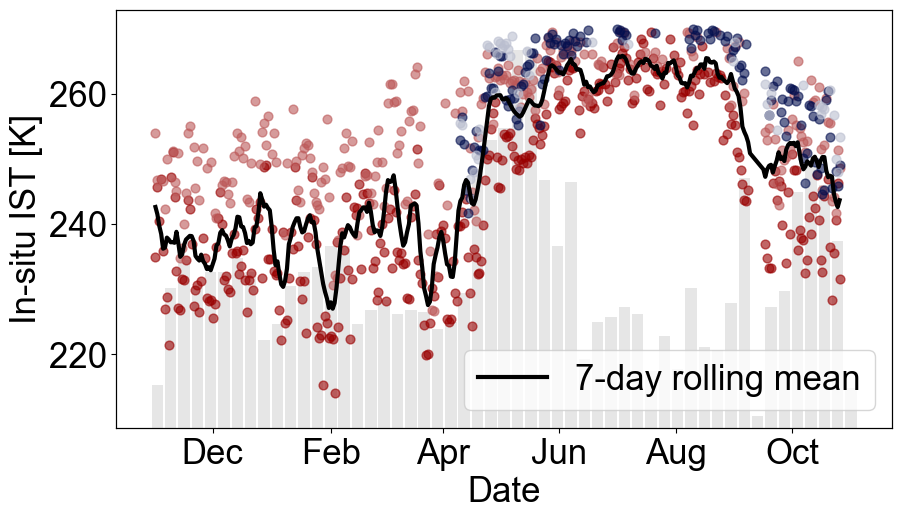

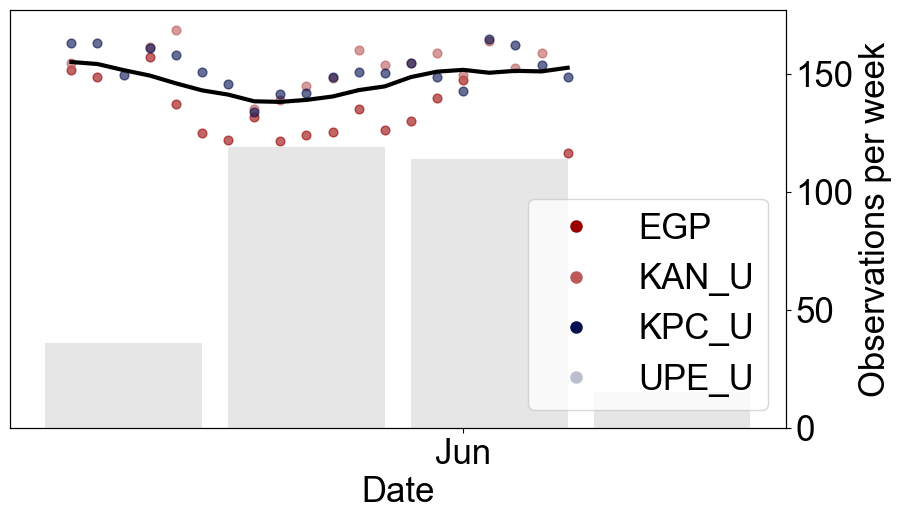

In [6]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "legend.fontsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
})

# Total observation histogram with raw TARGET measurement overlay
stations = ["EGP", "KAN_U", "KPC_U", "UPE_U"]

datasets = [
    (df_train, "2021", "W-MON", 6, "Observations per week"),
    (df_test, "2025", "W-MON", 6, "Observations per week"),
]

# --- Pre-compute shared y-axis limits across both datasets ---
temp_min, temp_max = np.inf, -np.inf      # left axis: In-situ IST [K]
obs_max = 0                                # right axis: observations per week
for df, title, freq, width, right_ylabel in datasets:
    d = df.copy()
    d["time"] = pd.to_datetime(d["lev1_obstime"])
    sub = d[d["station_id"].isin(stations)]
    if not sub.empty:
        temp_min = min(temp_min, sub[TARGET].min())
        temp_max = max(temp_max, sub[TARGET].max())
    counts = d.groupby(pd.Grouper(key="time", freq=freq))["station_id"].count()
    if not counts.empty:
        obs_max = max(obs_max, counts.max())

# Pad the limits slightly so points/bars aren't flush against the frame
temp_pad = (temp_max - temp_min) * 0.05
temp_ylim = (temp_min - temp_pad, temp_max + temp_pad)
obs_ylim = (0, obs_max * 1.10)

# --- Plot ---
for df, title, freq, width, right_ylabel in datasets:
    df = df.copy()
    df["time"] = pd.to_datetime(df["lev1_obstime"])
    total_counts = df.groupby(pd.Grouper(key="time", freq=freq))["station_id"].count()
    target_data = df[df["station_id"].isin(stations)][["time", "station_id", TARGET]]

    fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))
    ax2 = ax.twinx()

    # Put the main (scatter) axis on top of the bar axis
    ax2.set_zorder(1)
    ax2.patch.set_alpha(0.0)
    ax.set_zorder(2)
    ax.patch.set_alpha(0.0)

    ax2.bar(total_counts.index, total_counts.values,
            width=width, align="center", color=dtu_grey, alpha=0.65, zorder=1)
    ax2.set_ylabel(right_ylabel)

    # Per-station daily scatter points
    for station in stations:
        station_data = target_data[target_data["station_id"] == station].copy()
        if station_data.empty:
            continue
        station_data["time"] = pd.to_datetime(station_data["time"])
        daily = (
            station_data.set_index('time')
            .resample('D')[TARGET]
            .mean()
            .dropna()
        )
        if daily.empty:
            continue
        ax.scatter(daily.index, daily.values, label=station,
                   color=colors[station], s=40, zorder=3, alpha=0.6)

    # Single running weekly mean across ALL stations combined
    all_data = target_data.copy()
    all_data["time"] = pd.to_datetime(all_data["time"])
    daily_all = (
        all_data.set_index('time')
        .resample('D')[TARGET]
        .mean()
        .dropna()
    )
    mean_line = None
    if not daily_all.empty:
        daily_all_full = daily_all.reindex(
            pd.date_range(daily_all.index.min(), daily_all.index.max(), freq='D')
        )
        weekly_mean_all = daily_all_full.rolling(window=7, min_periods=3, center=True).mean()
        weekly_mean_all = weekly_mean_all.interpolate(method='time', limit=14)
        mean_line, = ax.plot(weekly_mean_all.index, weekly_mean_all.values,
                             color="black", linewidth=3.0, zorder=5,
                             label="Weekly mean")

    # Shared y-axis limits across both plots
    ax.set_ylim(*temp_ylim)
    ax2.set_ylim(*obs_ylim)

    ax.set_xlabel("Date")
    if title == "2021":
        ax.set_ylabel("In-situ IST [K]")
        # Rolling-mean legend only
        if mean_line is not None:
            ax.legend([mean_line], ["7-day rolling mean"], loc="lower right")
        ax2.yaxis.set_visible(False)   # no second y-axis on the 2021 plot
    else:
        ax.yaxis.set_visible(False)
        ax2.yaxis.set_label_position("right")
        ax2.yaxis.set_ticks_position("right")
        # Station legend showing ALL four stations, even those with no data this year
        station_handles = [
            Line2D([0], [0], marker='o', linestyle='None', markersize=8,
                   markerfacecolor=colors[s], markeredgecolor=colors[s], label=s)
            for s in stations
        ]
        ax.legend(handles=station_handles, loc="lower right")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    plt.tight_layout()
    plt.show()

In [7]:
#unc21 = pd.read_csv("ALL_filter_mu_atmo_surf_obs2345_promistK_v2.csv")
unc25 = df_test[["lev1_obstime","total_uncertainty", "station_id"]].dropna()
unc25.rename(columns={'total_uncertainty': 'unctot'}, inplace=True)

import csv

fn = "ALL_filter_mu_atmo_surf_obs2345_promistK_v2.csv"
# read and split header (it's comma-separated)
with open(fn, "r", encoding="utf-8", newline="") as f:
    header_line = f.readline().strip()
    colnames = [h.strip() for h in header_line.split(",")]
    sample = f.read(8192)
# sniff the delimiter used in the data rows
dialect = csv.Sniffer().sniff(sample, delimiters=",;\\t|")
sep = dialect.delimiter
# read the rest using detected sep and force the column names
unc21 = pd.read_csv(fn, sep=sep, header=None, names=colnames, skiprows=1, engine="python")
unc21.rename(columns={'"time': 'lev1_obstime'}, inplace=True)
#print(unc21)
unc21 = unc21[["lev1_obstime","unctot", "station_id"]].dropna()
print(unc21['unctot'])

0       2.02
1       1.01
2       0.52
3       1.01
4       1.01
        ... 
3425    0.52
3426    2.02
3427    1.01
3428    1.01
3429    1.01
Name: unctot, Length: 3430, dtype: float64


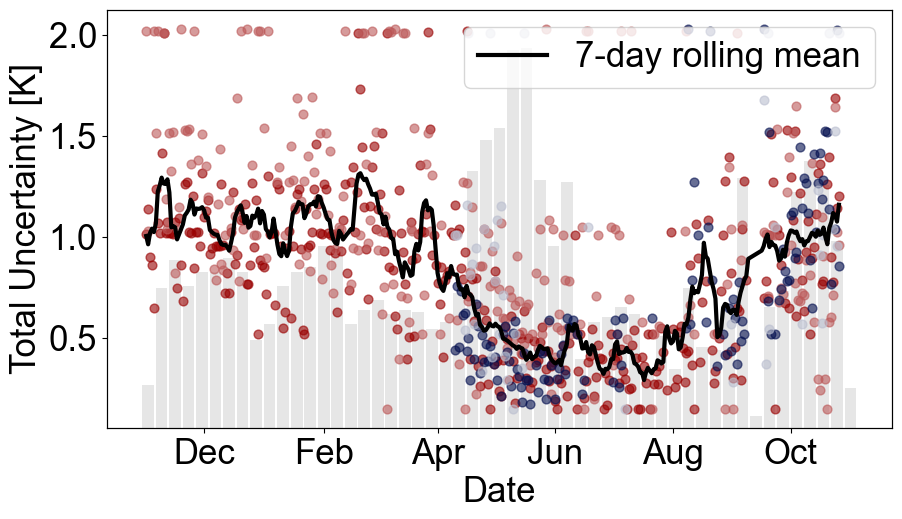

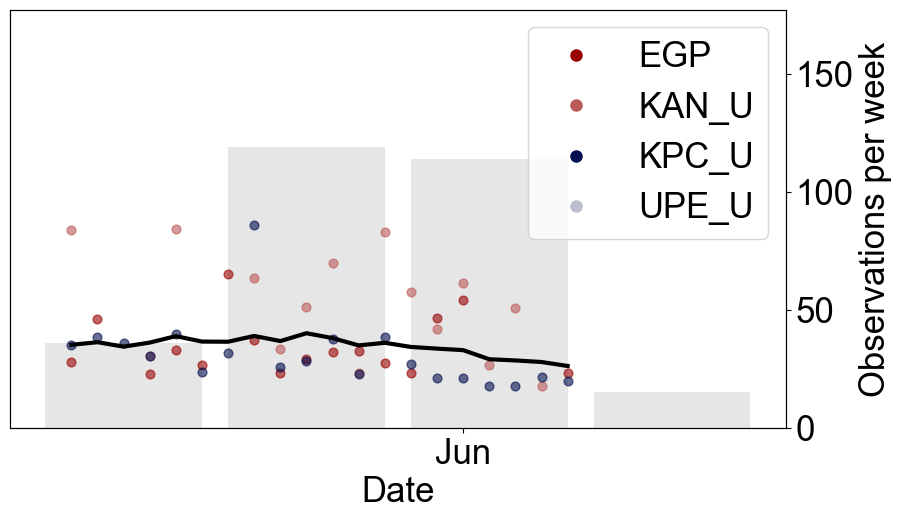

In [8]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "legend.fontsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
})

# Total uncertainty with observation-count bars
stations = ["EGP", "KAN_U", "KPC_U", "UPE_U"]

datasets = [
    (unc21, "2021", "W-MON", 6, "Observations per week"),
    (unc25, "2025", "W-MON", 6, "Observations per week"),
]

# --- Pre-compute shared y-axis limits across both datasets ---
unc_min, unc_max = np.inf, -np.inf      # left axis: Total Uncertainty [K]
obs_max = 0                              # right axis: observations per week
for df, title, freq, width, right_ylabel in datasets:
    d = df.copy()
    d["time"] = pd.to_datetime(d["lev1_obstime"])
    sub = d[d["station_id"].isin(stations)]
    if not sub.empty:
        unc_min = min(unc_min, sub['unctot'].min())
        unc_max = max(unc_max, sub['unctot'].max())
    counts = d.groupby(pd.Grouper(key="time", freq=freq))["station_id"].count()
    if not counts.empty:
        obs_max = max(obs_max, counts.max())

# Pad the limits slightly so points/bars aren't flush against the frame
unc_pad = (unc_max - unc_min) * 0.05
unc_ylim = (unc_min - unc_pad, unc_max + unc_pad)
obs_ylim = (0, obs_max * 1.10)

# --- Plot ---
for df, title, freq, width, right_ylabel in datasets:
    df = df.copy()
    df["time"] = pd.to_datetime(df["lev1_obstime"])
    total_counts = df.groupby(pd.Grouper(key="time", freq=freq))["station_id"].count()
    target_data = df[df["station_id"].isin(stations)][["time", "station_id", 'unctot']]

    fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))
    ax2 = ax.twinx()

    # Put the main (scatter) axis on top of the bar axis
    ax2.set_zorder(1)
    ax2.patch.set_alpha(0.0)
    ax.set_zorder(2)
    ax.patch.set_alpha(0.0)

    ax2.bar(total_counts.index, total_counts.values,
            width=width, align="center", color=dtu_grey, alpha=0.65, zorder=1)
    ax2.set_ylabel(right_ylabel)

    # Per-station daily scatter points
    for station in stations:
        station_data = target_data[target_data["station_id"] == station].copy()
        if station_data.empty:
            continue
        station_data["time"] = pd.to_datetime(station_data["time"])
        daily = (
            station_data.set_index('time')
            .resample('D')['unctot']
            .mean()
            .dropna()
        )
        if daily.empty:
            continue
        ax.scatter(daily.index, daily.values, label=station,
                   color=colors[station], s=40, zorder=3, alpha=0.6)

    # Single running weekly mean across ALL stations combined
    all_data = target_data.copy()
    all_data["time"] = pd.to_datetime(all_data["time"])
    daily_all = (
        all_data.set_index('time')
        .resample('D')['unctot']
        .mean()
        .dropna()
    )
    mean_line = None
    if not daily_all.empty:
        daily_all_full = daily_all.reindex(
            pd.date_range(daily_all.index.min(), daily_all.index.max(), freq='D')
        )
        weekly_mean_all = daily_all_full.rolling(window=7, min_periods=3, center=True).mean()
        weekly_mean_all = weekly_mean_all.interpolate(method='time', limit=14)
        mean_line, = ax.plot(weekly_mean_all.index, weekly_mean_all.values,
                             color="black", linewidth=3.0, zorder=5,
                             label="Weekly mean")

    # Shared y-axis limits across both plots
    ax.set_ylim(*unc_ylim)
    ax2.set_ylim(*obs_ylim)

    ax.set_xlabel("Date")
    if title == "2021":
        ax.set_ylabel("Total Uncertainty [K]")
        # Rolling-mean legend only
        if mean_line is not None:
            ax.legend([mean_line], ["7-day rolling mean"], loc="upper right")
        ax2.yaxis.set_visible(False)   # no second y-axis on the 2021 plot
    else:
        ax.yaxis.set_visible(False)
        ax2.yaxis.set_label_position("right")
        ax2.yaxis.set_ticks_position("right")
        # Station legend showing ALL four stations, even those with no data this year
        station_handles = [
            Line2D([0], [0], marker='o', linestyle='None', markersize=8,
                   markerfacecolor=colors[s], markeredgecolor=colors[s], label=s)
            for s in stations
        ]
        ax.legend(handles=station_handles, loc="upper right")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    plt.tight_layout()
    plt.show()